# Case Study 2 — Report 7

**Cross-dataset generalisation: DEAP → SEED (3-model comparison)**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Evaluate three candidate models trained on DEAP against SEED as an external test set. No SEED training. Direct transfer measures how well subject-independent emotion recognition trained on DEAP generalises to a different dataset.

**Models compared:**
1. **R4B MMD** — CNN-LSTM+Attention + MMD (linear, λ=0.1). Best on DEAP per-trial valence (65.31%).
2. **R5 full** — Same as R4B + source reliability weighting + confidence-routed dual head. Techniques that stabilised MMD collapse and may help transfer by down-weighting DEAP subjects that don't generalise.
3. **R4B plain** — CNN-LSTM+Attention with no DA. Control: does MMD actually help transfer, or just help within-dataset?

**Test configurations:**
- Label mapping: **binary** (Neg vs Pos, SEED Neutral excluded) and **3-class** (Neg/Neu/Pos direct).
- Protocol: **per-trial** and **per-window** on SEED.

**Grid.** 3 models × 2 mappings × 2 protocols = 12 test runs.

**Reference:** Imtiaz & Khan 2024 report 67.44% DEAP → SEED binary with DA.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import torch, numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path
from tqdm.auto import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)
from sklearn.linear_model import LogisticRegression

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [3]:
CONFIG = {
    # DEAP
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',
    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    # SEED
    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    # Per-trial SEED (from local preprocessing — Method B, DE computed per full film)
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',
    'seed_n_subjects':    15,
    'seed_n_trials':      45,        # 15 films × 3 sessions

    'results_dir':  'results/report7_crossdataset_v2',

    # Training
    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,

    # R5 specific
    'confidence_threshold': 0.7,
    'he_alpha':      0.5,
    'reliability_warmup': 3,
}

RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load DEAP + SEED, aggregate to per-trial

In [4]:
root = Path(PROJECT_ROOT)

# DEAP
X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)
print(f'DEAP per-window: {X_deap_pw.shape}')

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)
print(f'DEAP per-trial (Method A aggregation): {X_deap_pt.shape}')

# SEED per-window (from R1 preprocessing on Drive)
X_seed_pw = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed    = np.load(root / CONFIG['seed_labels']).astype(np.int64)
print(f'SEED per-window: {X_seed_pw.shape}')

# SEED per-trial (from local preprocessing — Method B, one DE vector per full film)
X_seed_pt   = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)
print(f'SEED per-trial (from local preprocessing): {X_seed_pt.shape}')
print(f'SEED per-trial label counts: {np.bincount(y_seed_pt).tolist()}')
print(f'SEED per-trial subjects: {np.unique(subj_seed_pt).tolist()}')
print(f'SEED per-trial trials/subject: {[int((subj_seed_pt==s).sum()) for s in range(1,16)]}')

DEAP per-window: (152320, 160)
DEAP per-trial (Method A aggregation): (1280, 160)
SEED per-window: (304785, 160)
SEED per-trial (from local preprocessing): (675, 160)
SEED per-trial label counts: [225, 225, 225]
SEED per-trial subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
SEED per-trial trials/subject: [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45]


## 4. Label mapping DEAP ↔ SEED

**Binary:** DEAP {Low, High} ↔ SEED {Neg, Pos}. SEED Neutral excluded (no DEAP binary equivalent).

**3-class:** Direct {Neg, Neu, Pos} mapping.

In [5]:
def map_seed_to_binary(X, y, subj):
    mask = (y == 0) | (y == 2)
    return X[mask], (y[mask] == 2).astype(np.int64), subj[mask]

def map_seed_to_3class(X, y, subj):
    return X, y.astype(np.int64), subj

TEST_SETS = {}
X_b_pt, y_b_pt, s_b_pt = map_seed_to_binary(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('binary', 'per_trial')] = (X_b_pt, y_b_pt, s_b_pt)

X_3_pt, y_3_pt, s_3_pt = map_seed_to_3class(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('3class', 'per_trial')] = (X_3_pt, y_3_pt, s_3_pt)

X_b_pw, y_b_pw, s_b_pw = map_seed_to_binary(X_seed_pw, y_seed, subj_seed)
TEST_SETS[('binary', 'per_window')] = (X_b_pw, y_b_pw, s_b_pw)

X_3_pw, y_3_pw, s_3_pw = map_seed_to_3class(X_seed_pw, y_seed, subj_seed)
TEST_SETS[('3class', 'per_window')] = (X_3_pw, y_3_pw, s_3_pw)

for k, v in TEST_SETS.items():
    print(f'{k}: {v[0].shape}, class counts: {np.bincount(v[1])}')

('binary', 'per_trial'): (450, 160), class counts: [225 225]
('3class', 'per_trial'): (675, 160), class counts: [225 225 225]
('binary', 'per_window'): (205650, 160), class counts: [100575 105075]
('3class', 'per_window'): (304785, 160), class counts: [100575  99135 105075]


## 5. Shared model pieces

In [6]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

## 6. Three model variants

- **`SingleHeadModel`** — CNN-LSTM+Attn + one classifier head. Used by R4B MMD and R4B plain.
- **`DualHeadModel`** — CNN-LSTM+Attn + easy/hard classifier heads. Used by R5 full.

In [7]:
class SingleHeadModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor  = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        if return_features:
            return logits, feat
        return logits

class DualHeadModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor = CNNLSTMAttentionExtractor()
        self.head_easy = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
        self.head_hard = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        e = self.head_easy(feat)
        h = self.head_hard(feat)
        if return_features:
            return e, h, feat
        return e, h
    def combined_logits(self, logits_easy, logits_hard, alpha=0.5):
        p_e = F.softmax(logits_easy, dim=1)
        p_h = F.softmax(logits_hard, dim=1)
        return torch.log(alpha * p_e + (1 - alpha) * p_h + 1e-10)

## 7. Source reliability weighting (for R5 full model)

For each DEAP training subject, compute how well a fast LogisticRegression trained on the other 31 predicts this subject's labels. Score in [0.2, 2.0] used as per-sample loss multiplier.

In [8]:
def compute_source_reliability(X_np, y_np, s_np, n_classes):
    unique_subs = np.unique(s_np)
    weights = {}
    for sub in unique_subs:
        tr = s_np != sub; te = s_np == sub
        try:
            clf = LogisticRegression(max_iter=200, C=1.0, class_weight='balanced')
            clf.fit(X_np[tr], y_np[tr])
            bal = balanced_accuracy_score(y_np[te], clf.predict(X_np[te]))
        except Exception:
            bal = 1.0 / n_classes
        chance = 1.0 / n_classes
        raw = 2.0 * (bal - chance)
        weights[int(sub)] = max(0.2, min(2.0, 1.0 + raw))
    return weights

## 8. Training functions — one per model variant

In [9]:
def train_r4b_mmd(X_train_np, y_train_np, subj_train_np,
                  X_test_np, y_test_np, n_classes,
                  epochs, batch_size, lr, wd, mmd_lambda):
    """R4B MMD: CNN-LSTM+Attn with MMD alignment loss."""
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_te = torch.from_numpy(X_test_np).to(DEVICE)

    # Remap subject IDs
    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = SingleHeadModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_bal, best_preds = -1.0, None
    n = X_tr.size(0)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]
            opt.zero_grad()
            logits, feat = model(xb, return_features=True)
            loss = loss_fn(logits, yb) + mmd_lambda * linear_mmd_by_subject(feat, sb)
            loss.backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            preds = []
            for i in range(0, X_te.size(0), batch_size*2):
                preds.append(model(X_te[i:i+batch_size*2]).argmax(dim=1))
            y_pred = torch.cat(preds).cpu().numpy()
        bal = balanced_accuracy_score(y_test_np, y_pred)
        if bal > best_bal:
            best_bal, best_preds = bal, y_pred.copy()
    return best_preds, best_bal

In [10]:
def train_r4b_plain(X_train_np, y_train_np, subj_train_np,
                    X_test_np, y_test_np, n_classes,
                    epochs, batch_size, lr, wd):
    """R4B plain: CNN-LSTM+Attn, cross-entropy only (no DA)."""
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    X_te = torch.from_numpy(X_test_np).to(DEVICE)

    model = SingleHeadModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_bal, best_preds = -1.0, None
    n = X_tr.size(0)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb, yb = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            preds = []
            for i in range(0, X_te.size(0), batch_size*2):
                preds.append(model(X_te[i:i+batch_size*2]).argmax(dim=1))
            y_pred = torch.cat(preds).cpu().numpy()
        bal = balanced_accuracy_score(y_test_np, y_pred)
        if bal > best_bal:
            best_bal, best_preds = bal, y_pred.copy()
    return best_preds, best_bal

In [11]:
def train_r5_full(X_train_np, y_train_np, subj_train_np,
                  X_test_np, y_test_np, n_classes,
                  epochs, batch_size, lr, wd, mmd_lambda,
                  conf_threshold, he_alpha, reliab_warmup):
    """R5 full: reliability-weighted + hard-easy dual head + MMD."""
    # Reliability weights on CPU
    reliab_dict = compute_source_reliability(X_train_np, y_train_np, subj_train_np, n_classes)

    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_te = torch.from_numpy(X_test_np).to(DEVICE)

    reliab_arr = np.array([reliab_dict.get(int(s), 1.0) for s in subj_train_np], dtype=np.float32)
    reliab_gpu = torch.from_numpy(reliab_arr).to(DEVICE)

    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = DualHeadModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE),
                                  reduction='none')

    best_bal, best_preds = -1.0, None
    n = X_tr.size(0)
    for ep in range(epochs):
        model.train()
        apply_reliab = ep >= reliab_warmup
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]
            wb = reliab_gpu[idx] if apply_reliab else torch.ones_like(reliab_gpu[idx])
            opt.zero_grad()
            logits_e, logits_h, feat = model(xb, return_features=True)
            loss_e = loss_fn(logits_e, yb)
            loss_h = loss_fn(logits_h, yb)
            with torch.no_grad():
                conf_e = F.softmax(logits_e, dim=1).max(dim=1).values
                easy_mask = (conf_e >= conf_threshold).float()
                hard_mask = (conf_e <  conf_threshold).float()
            label_loss = ((loss_e * (0.5 + 0.5*easy_mask) + loss_h * (0.5 + 0.5*hard_mask)) * wb).mean()
            loss = label_loss + mmd_lambda * linear_mmd_by_subject(feat, sb)
            loss.backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            preds = []
            for i in range(0, X_te.size(0), batch_size*2):
                le, lh = model(X_te[i:i+batch_size*2])
                combined = model.combined_logits(le, lh, alpha=he_alpha)
                preds.append(combined.argmax(dim=1))
            y_pred = torch.cat(preds).cpu().numpy()
        bal = balanced_accuracy_score(y_test_np, y_pred)
        if bal > best_bal:
            best_bal, best_preds = bal, y_pred.copy()
    return best_preds, best_bal

## 9. Main loop — 3 models × 2 mappings × 2 protocols = 12 runs

For each (model, mapping, protocol) triple: train on DEAP with matching mapping/protocol, test on the matching SEED set.

In [12]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

MODELS = ['r4b_mmd', 'r5_full', 'r4b_plain']

ALL_RESULTS = {}
for model_name in MODELS:
    for (mapping, protocol), (X_test, y_test, s_test) in TEST_SETS.items():
        key = (model_name, mapping, protocol)
        print(f'\n{"="*60}\n[{model_name}] {mapping} × {protocol}\n{"="*60}')

        X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
        n_classes = 3 if mapping == '3class' else 2

        # Protocol-dependent hyperparameters
        if protocol == 'per_window':
            batch = 512; epochs = 20
        else:
            batch = 128; epochs = 40

        t0 = time.time()
        if model_name == 'r4b_mmd':
            y_pred, best_bal = train_r4b_mmd(
                X_train, y_train, subj_train, X_test, y_test,
                n_classes, epochs, batch,
                CONFIG['lr'], CONFIG['weight_decay'], CONFIG['mmd_lambda'])
        elif model_name == 'r4b_plain':
            y_pred, best_bal = train_r4b_plain(
                X_train, y_train, subj_train, X_test, y_test,
                n_classes, epochs, batch,
                CONFIG['lr'], CONFIG['weight_decay'])
        elif model_name == 'r5_full':
            y_pred, best_bal = train_r5_full(
                X_train, y_train, subj_train, X_test, y_test,
                n_classes, epochs, batch,
                CONFIG['lr'], CONFIG['weight_decay'], CONFIG['mmd_lambda'],
                CONFIG['confidence_threshold'], CONFIG['he_alpha'],
                CONFIG['reliability_warmup'])
        elapsed = time.time() - t0

        ALL_RESULTS[key] = {
            'y_true': y_test, 'y_pred': y_pred,
            'best_bal': best_bal, 'elapsed_s': elapsed,
            'n_train': X_train.shape[0], 'n_test': X_test.shape[0],
        }
        print(f'  best SEED bal={100*best_bal:.2f}%  time={elapsed:.1f}s')

        del X_train, y_train, subj_train
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()


[r4b_mmd] binary × per_trial
  best SEED bal=66.67%  time=19.3s

[r4b_mmd] 3class × per_trial
  best SEED bal=46.07%  time=8.8s

[r4b_mmd] binary × per_window
  best SEED bal=66.81%  time=141.7s

[r4b_mmd] 3class × per_window
  best SEED bal=45.04%  time=149.4s

[r5_full] binary × per_trial
  best SEED bal=64.00%  time=8.8s

[r5_full] 3class × per_trial


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  best SEED bal=47.56%  time=11.5s

[r5_full] binary × per_window
  best SEED bal=66.10%  time=213.3s

[r5_full] 3class × per_window


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  best SEED bal=44.30%  time=388.2s

[r4b_plain] binary × per_trial
  best SEED bal=67.11%  time=2.1s

[r4b_plain] 3class × per_trial
  best SEED bal=43.56%  time=2.1s

[r4b_plain] binary × per_window
  best SEED bal=65.67%  time=64.7s

[r4b_plain] 3class × per_window
  best SEED bal=44.76%  time=75.6s


## 10. Aggregate + save

In [13]:
rows = []
for (model_name, mapping, protocol), r in ALL_RESULTS.items():
    y_true, y_pred = r['y_true'], r['y_pred']
    n_classes = 3 if mapping == '3class' else 2
    chance = 100.0 / n_classes
    acc = 100 * accuracy_score(y_true, y_pred)
    bal = 100 * balanced_accuracy_score(y_true, y_pred)
    f1w = 100 * f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = 100 * precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = 100 * recall_score(y_true, y_pred, average='macro', zero_division=0)
    rows.append({
        'model': model_name, 'mapping': mapping, 'protocol': protocol,
        'accuracy': acc, 'bal_accuracy': bal,
        'f1_weighted': f1w, 'precision_macro': prec, 'recall_macro': rec,
        'chance': chance, 'gap_from_chance': bal - chance,
        'n_test': r['n_test'],
    })

SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_crossdataset.csv', index=False)
print(SUMMARY.to_string(index=False))

    model mapping   protocol  accuracy  bal_accuracy  f1_weighted  precision_macro  recall_macro    chance  gap_from_chance  n_test
  r4b_mmd  binary  per_trial 66.666667     66.666667    66.103567        67.852987     66.666667 50.000000        16.666667     450
  r4b_mmd  3class  per_trial 46.074074     46.074074    41.739845        47.344872     46.074074 33.333333        12.740741     675
  r4b_mmd  binary per_window 66.701191     66.809908    66.634619        66.945318     66.809908 50.000000        16.809908  205650
  r4b_mmd  3class per_window 45.491084     45.040635    42.193825        43.992990     45.040635 33.333333        11.707302  304785
  r5_full  binary  per_trial 64.000000     64.000000    62.884897        65.912306     64.000000 50.000000        14.000000     450
  r5_full  3class  per_trial 47.555556     47.555556    47.132050        47.677818     47.555556 33.333333        14.222222     675
  r5_full  binary per_window 66.296134     66.100549    66.006129        66.

In [14]:
# Save confusion matrices
for (model_name, mapping, protocol), r in ALL_RESULTS.items():
    n_classes = 3 if mapping == '3class' else 2
    cm = confusion_matrix(r['y_true'], r['y_pred'], labels=list(range(n_classes)))
    np.save(RESULTS_DIR / f'cm_{model_name}_{mapping}_{protocol}.npy', cm)

## 11. Plots

In [15]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

### 11.1 Model comparison — all 12 configurations

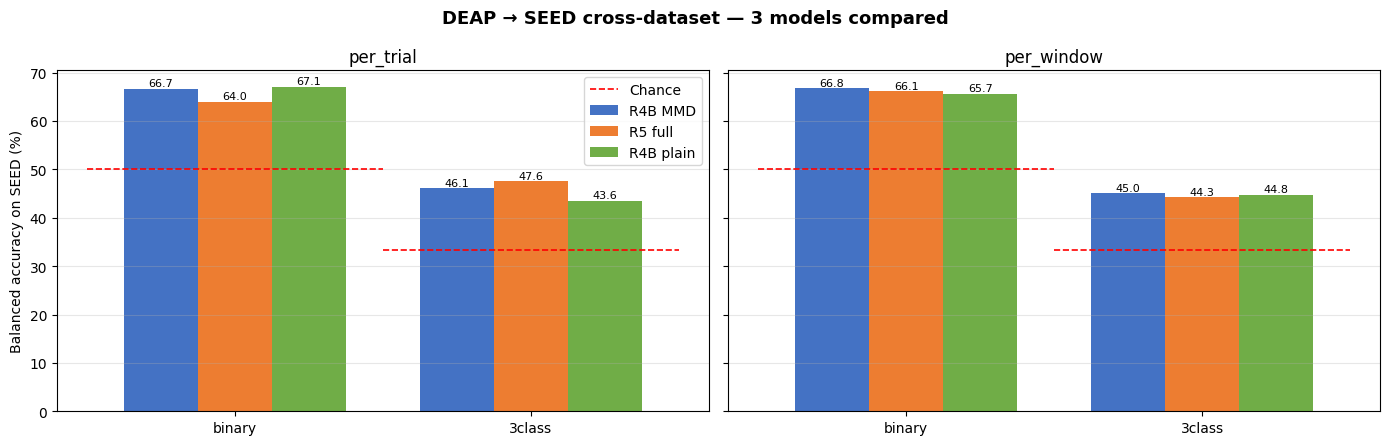

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
model_colors = {'r4b_mmd': '#4472C4', 'r5_full': '#ED7D31', 'r4b_plain': '#70AD47'}
model_labels = {'r4b_mmd': 'R4B MMD', 'r5_full': 'R5 full', 'r4b_plain': 'R4B plain'}

for ax, protocol in zip(axes, ['per_trial', 'per_window']):
    mappings = ['binary', '3class']
    x = np.arange(len(mappings))
    w = 0.25
    for i, model in enumerate(MODELS):
        vals = []
        for m in mappings:
            key = (model, m, protocol)
            vals.append(SUMMARY[(SUMMARY['model']==model) &
                                (SUMMARY['mapping']==m) &
                                (SUMMARY['protocol']==protocol)]['bal_accuracy'].iloc[0])
        offset = (i - 1) * w
        bars = ax.bar(x + offset, vals, w, label=model_labels[model], color=model_colors[model])
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}',
                    ha='center', fontsize=8)
    # Chance lines
    for i, m in enumerate(mappings):
        ch = 50.0 if m == 'binary' else 33.3
        ax.hlines(ch, x[i]-0.5, x[i]+0.5, colors='red', linestyles='dashed',
                  linewidth=1.2, label='Chance' if i == 0 else '')
    ax.set_xticks(x); ax.set_xticklabels(mappings)
    ax.set_title(protocol); ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Balanced accuracy on SEED (%)')
axes[0].legend()
plt.suptitle('DEAP → SEED cross-dataset — 3 models compared', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'r7_model_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

### 11.2 Comparison vs published SOTA (binary)

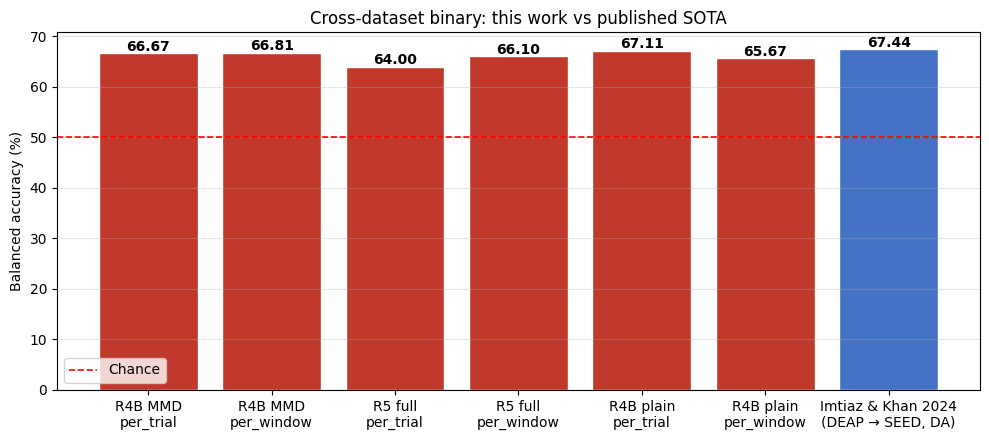


Best result: R4B plain on per_trial: 67.11%


In [17]:
# Best binary result across all models × protocols
binary_rows = SUMMARY[SUMMARY['mapping']=='binary'].copy()
best_row = binary_rows.loc[binary_rows['bal_accuracy'].idxmax()]

labels, vals, colors = [], [], []
for _, row in binary_rows.iterrows():
    labels.append(f'{model_labels[row["model"]]}\n{row["protocol"]}')
    vals.append(row['bal_accuracy'])
    colors.append('#c0392b')
labels.append('Imtiaz & Khan 2024\n(DEAP → SEED, DA)')
vals.append(67.44); colors.append('#4472C4')

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, vals, color=colors, edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Chance')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title('Cross-dataset binary: this work vs published SOTA')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'r7_vs_sota.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'\nBest result: {model_labels[best_row["model"]]} on {best_row["protocol"]}: {best_row["bal_accuracy"]:.2f}%')

### 11.3 Confusion matrices — best model per config

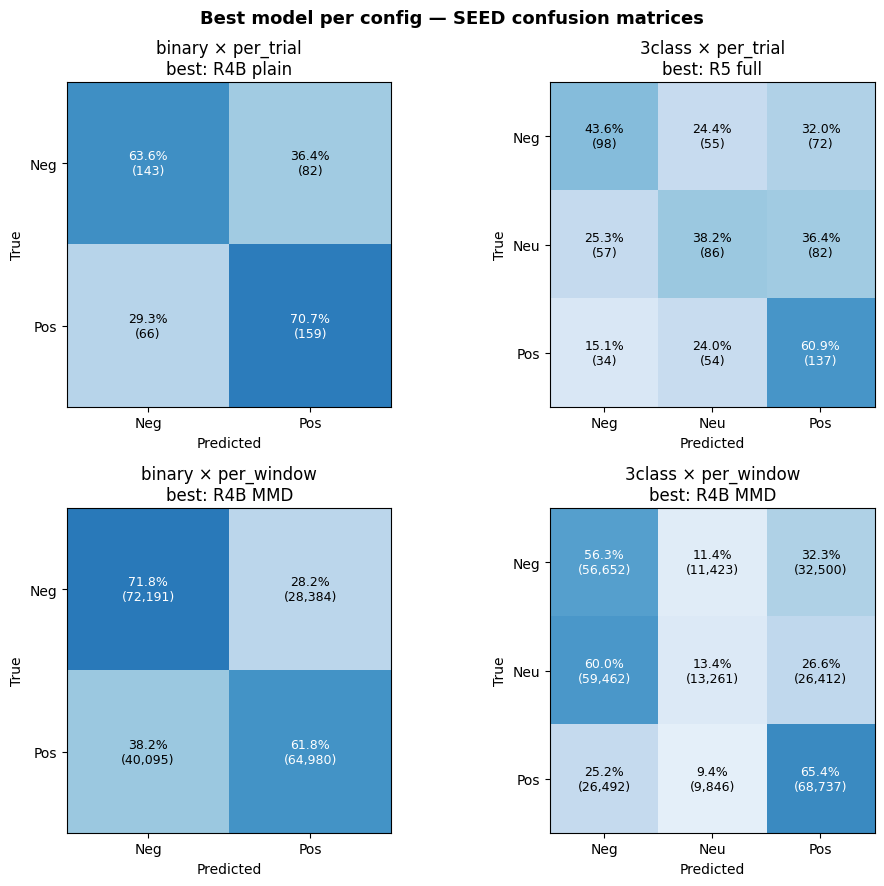

In [18]:
# 4 configs, plot best-model confusion for each
best_per_config = {}
for (m_, p_), _ in TEST_SETS.items():
    sub = SUMMARY[(SUMMARY['mapping']==m_) & (SUMMARY['protocol']==p_)]
    best_row = sub.loc[sub['bal_accuracy'].idxmax()]
    best_per_config[(m_, p_)] = best_row['model']

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, ((mapping, protocol), best_model) in zip(axes.flat, best_per_config.items()):
    n_classes = 3 if mapping == '3class' else 2
    r = ALL_RESULTS[(best_model, mapping, protocol)]
    cm = confusion_matrix(r['y_true'], r['y_pred'], labels=list(range(n_classes))).astype(float)
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-10) * 100
    names = ['Neg', 'Pos'] if mapping == 'binary' else ['Neg', 'Neu', 'Pos']
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(n_classes):
        for j in range(n_classes):
            c = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i, j]:.1f}%\n({int(cm[i, j]):,})',
                    ha='center', va='center', color=c, fontsize=9)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{mapping} × {protocol}\nbest: {model_labels[best_model]}')
plt.suptitle('Best model per config — SEED confusion matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'r7_confusion_best.png', dpi=140, bbox_inches='tight')
plt.show()